# Cost–Time Plan Optimization

In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Cofi import style
%matplotlib inline

style.apply()
FONT_SIZE = style.FONT_SIZE
DATA, FIG = "data", "figures"
os.makedirs(FIG, exist_ok=True)
pd.set_option("display.width", 160)
qnum = lambda q: int("".join(c for c in q if c.isdigit()) or 0)

PL = pd.read_csv(f"{DATA}/plans.csv")
PTS = pd.read_csv(f"{DATA}/points.csv")
CHK = pd.read_csv(f"{DATA}/p-check.csv")
PTS["C"] = PTS["C"] * style.COST_SCALE
PLANS = {(r.query, r.plan): r for r in PL.itertuples()}
QS = sorted(PL["query"].unique(), key=qnum)
print(f"functions per stage, simulated == measured at the default size: {(CHK.p_meas == CHK.p_sim).sum()}/{len(CHK)}")

functions per stage, simulated == measured at the default size: 276/290


## Default plan, Bloom-filter build cost and saving (estimated)

In [2]:
BT = pd.read_csv(f"{DATA}/bf-tradeoff.csv").set_index("query").reindex(QS)
S = style.COST_SCALE
show = pd.DataFrame({
    "BFs": BT["n_bf"],
    "T no BF (s)": BT["T_no_bf_s"], "T default (s)": BT["T_default_s"], "T BF build (s)": BT["T_bf_build_s"],
    "T saving net (s)": BT["T_saving_net_s"], "T knee (s)": BT["T_knee_s"],
    f"C no BF ({style.COST_UNIT})": BT["C_no_bf_usd"] * S, f"C default ({style.COST_UNIT})": BT["C_default_usd"] * S,
    f"C BF build ({style.COST_UNIT})": BT["C_bf_build_usd"] * S, f"C saving net ({style.COST_UNIT})": BT["C_saving_net_usd"] * S,
    f"C knee ({style.COST_UNIT})": BT["C_knee_usd"] * S,
})
show.loc["total"] = show.sum()
show.index = [q.upper() for q in show.index]
show.round(3)

,BFs,T no BF (s),T default (s),T BF build (s),T saving net (s),T knee (s),C no BF (¢),C default (¢),C BF build (¢),C saving net (¢),C knee (¢)
Q2,5.0,7.019,4.466,0.720,2.552,3.993,0.478,0.159,0.028,0.319,0.161
Q3,2.0,16.783,15.073,2.828,1.709,12.221,4.216,1.762,0.262,2.455,1.613
Q4,1.0,5.806,7.515,2.678,-1.709,5.544,0.643,0.590,0.204,0.054,0.660
Q5,2.0,36.217,23.829,0.272,12.388,24.240,13.235,6.461,0.006,6.774,6.146
Q7,1.0,48.147,19.739,0.216,28.408,18.796,23.548,4.543,0.006,19.006,3.546
Q8,3.0,76.340,16.579,1.346,59.761,12.330,35.351,2.267,0.207,33.084,1.954
Q9,1.0,54.208,33.555,1.624,20.653,28.896,18.062,7.862,0.231,10.200,7.371
Q10,2.0,24.070,22.567,1.783,1.502,19.154,6.630,5.081,0.211,1.549,5.035
Q11,3.0,6.723,6.334,0.591,0.388,3.600,0.532,0.160,0.028,0.372,0.210
Q12,1.0,7.398,6.938,1.146,0.460,5.052,1.151,0.794,0.052,0.357,0.567


In [3]:
tot = BT.sum(numeric_only=True)
summ = pd.DataFrame({
    "No BF": [tot["T_no_bf_s"], tot["C_no_bf_usd"] * S],
    "Default (BF always on)": [tot["T_default_s"], tot["C_default_usd"] * S],
    "of which BF build": [tot["T_bf_build_s"], tot["C_bf_build_usd"] * S],
    "Saving gross (data reduced by the BFs)": [tot["T_saving_gross_s"], tot["C_saving_gross_usd"] * S],
    "Saving net = No BF − Default": [tot["T_saving_net_s"], tot["C_saving_net_usd"] * S],
    "Knee (optimized)": [tot["T_knee_s"], tot["C_knee_usd"] * S],
}, index=["T over 19 queries (s)", f"C over 19 queries ({style.COST_UNIT})"]).T
summ["ΔT vs default"] = (summ.iloc[:, 0] / summ.loc["Default (BF always on)"].iloc[0] - 1).map("{:+.0%}".format)
summ["ΔC vs default"] = (summ.iloc[:, 1] / summ.loc["Default (BF always on)"].iloc[1] - 1).map("{:+.0%}".format)
summ.loc[["of which BF build", "Saving gross (data reduced by the BFs)", "Saving net = No BF − Default"], ["ΔT vs default", "ΔC vs default"]] = ""
summ.round(2)

,T over 19 queries (s),C over 19 queries (¢),ΔT vs default,ΔC vs default
No BF,442.23,137.80,+56%,+167%
Default (BF always on),283.14,51.63,+0%,+0%
of which BF build,26.86,2.65,,
Saving gross (data reduced by the BFs),185.95,88.82,,
Saving net = No BF − Default,159.09,86.17,,
Knee (optimized),236.18,44.78,-17%,-13%


## Knee plan & Default plan

In [5]:
rows = []
for q in QS:
    d, k = PLANS[(q, "default")], PLANS[(q, "knee")]
    rows.append({"query": q.upper(), "T default (s)": d.T_est_s, "T knee (s)": k.T_est_s, "ΔT": f"{k.T_est_s / d.T_est_s - 1:+.0%}",
                 f"C default ({style.COST_UNIT})": d.C_est_usd * style.COST_SCALE, f"C knee ({style.COST_UNIT})": k.C_est_usd * style.COST_SCALE,
                 "ΔC": f"{k.C_est_usd / d.C_est_usd - 1:+.0%}", "BFs off": len(str(k.bf_off).split()) if isinstance(k.bf_off, str) else 0,
                 "stages resized": len(json.loads(k.max_size_mb)), "plans evaluated": int((PTS["query"] == q).sum())})
pd.DataFrame(rows).set_index("query").round(3)

,T default (s),T knee (s),ΔT,C default (¢),C knee (¢),ΔC,BFs off,stages resized,plans evaluated
query,,,,,,,,,
Q2,4.466,3.993,-11%,0.159,0.161,+1%,3,3,805
Q3,15.073,12.221,-19%,1.762,1.613,-8%,0,5,944
Q4,7.515,5.544,-26%,0.590,0.660,+12%,1,3,385
Q5,23.829,24.240,+2%,6.461,6.146,-5%,1,6,1254
Q7,19.739,18.796,-5%,4.543,3.546,-22%,0,5,1076
Q8,16.579,12.330,-26%,2.267,1.954,-14%,1,7,1475
Q9,33.555,28.896,-14%,7.862,7.371,-6%,0,9,1587
Q10,22.567,19.154,-15%,5.081,5.035,-1%,0,6,838
Q11,6.334,3.600,-43%,0.160,0.210,+31%,1,6,578


## Pareto fronts

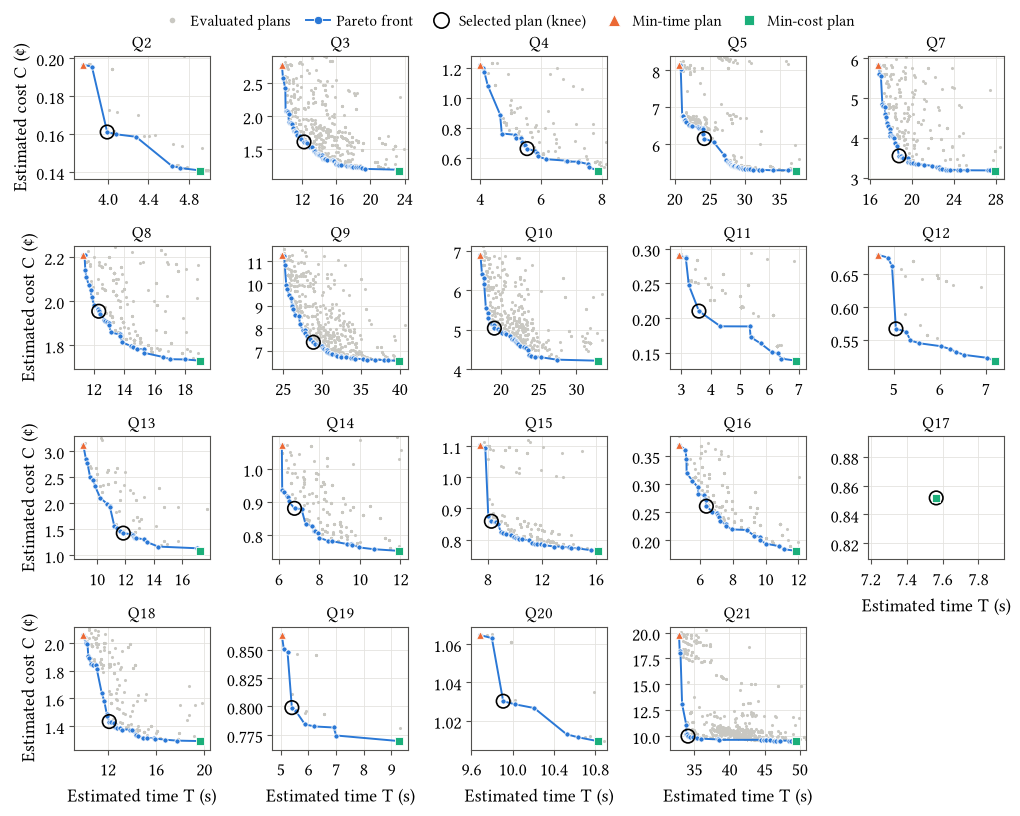

In [6]:
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
GRAY, BLUE, ORANGE, GREEN = "#c9c8c2", "#2a78d6", "#eb6834", "#1baf7a"
PAD = 0.08


def panel(ax, q):
    R = PTS[PTS["query"] == q]
    F = R[R.pareto].sort_values("T")
    ax.scatter(R["T"], R["C"], s=5, color=GRAY, lw=0, rasterized=True)
    ax.plot(F["T"], F["C"], color=BLUE, lw=1.4, zorder=2)
    ax.scatter(F["T"], F["C"], s=14, color=BLUE, edgecolor="white", lw=0.6, zorder=3)
    k = PLANS[(q, "knee")]
    ax.scatter([k.T_est_s], [k.C_est_usd * style.COST_SCALE], s=95, facecolor="none", edgecolor="black", lw=1.2, zorder=4)
    for key, mk, col in (("min_T", "^", ORANGE), ("min_C", "s", GREEN)):
        p = PLANS[(q, key)]
        ax.scatter([p.T_est_s], [p.C_est_usd * style.COST_SCALE], marker=mk, s=30, color=col, edgecolor="white", lw=0.6, zorder=5)
    ax.set_title(q.upper(), fontsize=FONT_SIZE - 1)
    ax.grid(True, color=style.GRID, lw=0.6); ax.set_axisbelow(True)
    for vals, setlim in ((F["T"], ax.set_xlim), (F["C"], ax.set_ylim)):
        lo, hi = vals.min(), vals.max()
        pad = (hi - lo) * PAD or lo * 0.05
        setlim(lo - pad, hi + pad)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4, steps=[1, 2, 4, 5, 10], min_n_ticks=3))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, steps=[1, 2, 2.5, 5, 10], min_n_ticks=3))


def figure(queries, name, ncol=3):
    nrow = -(-len(queries) // ncol)
    height = 1.9 * nrow + 0.5
    fig, axs = plt.subplots(nrow, ncol, figsize=(1.95 * ncol + 0.3, height), squeeze=False)
    for ax, q in zip(axs.flat, queries):
        panel(ax, q)
    for ax in list(axs.flat)[len(queries):]:
        ax.axis("off")
    for ax in axs[:, 0]:
        ax.set_ylabel(f"Estimated cost C ({style.COST_UNIT})")
    for c in range(ncol):
        used = [axs[r, c] for r in range(nrow) if r * ncol + c < len(queries)]
        if used:
            used[-1].set_xlabel("Estimated time T (s)")
    mk = lambda m, ms, fc, ec="white", mew=0.6: Line2D([], [], ls="", marker=m, ms=ms, mfc=fc, mec=ec, mew=mew)
    h = [mk("o", 4, GRAY, GRAY, 0), Line2D([], [], color=BLUE, lw=1.4, marker="o", ms=6, mfc=BLUE, mec="white", mew=0.6),
         mk("o", 11, "none", "black", 1.2), mk("^", 8, ORANGE), mk("s", 7, GREEN)]
    l = ["Evaluated plans", "Pareto front", "Selected plan (knee)", "Min-time plan", "Min-cost plan"]
    leg_ncol = 5 if ncol >= 4 else 3
    leg_rows = -(-len(l) // leg_ncol)
    fig.legend(h, l, loc="upper center", ncol=leg_ncol, frameon=False, bbox_to_anchor=(0.5, 1.0), fontsize=FONT_SIZE - 2,
               handlelength=1.6, handletextpad=0.4, columnspacing=1.0, labelspacing=0.3, borderpad=0.2)
    fig.tight_layout(pad=0.3, w_pad=0.8, h_pad=0.6, rect=(0, 0, 1, 1 - 0.26 * leg_rows / height))
    style.save(fig, FIG, name)
    plt.show()

figure(QS, "pareto-opt-all", ncol=5)

# Validate Pareto front (measured)

In [7]:
VR = pd.read_csv(f"{DATA}/validation-runs.csv")
VR["C"] = VR["C_usd"] * style.COST_SCALE
MEAS = VR.groupby(["query", "plan"]).agg(runs=("T_s", "size"), T=("T_s", "median"), T_lo=("T_s", "min"), T_hi=("T_s", "max"),
                                         C=("C", "median"), C_lo=("C", "min"), C_hi=("C", "max")).reset_index()
V = PL.merge(MEAS, left_on=["query", "run_as"], right_on=["query", "plan"], suffixes=("", "_m")).drop(columns="plan_m")
V["T_est"], V["C_est"] = V["T_est_s"], V["C_est_usd"] * style.COST_SCALE
V["err_T_%"] = 100 * (V["T_est"] / V["T"] - 1)
V["err_C_%"] = 100 * (V["C_est"] / V["C"] - 1)
VQ = sorted(V["query"].unique(), key=qnum)
print(f"measured: {len(VQ)} of {PL['query'].nunique()} queries ({', '.join(q.upper() for q in VQ)}), "
      f"{len(V.drop_duplicates(['query', 'run_as']))} distinct plans run, {len(VR)} runs")
V[["query", "plan", "run_as", "T_est", "T", "err_T_%", "C_est", "C", "err_C_%", "runs"]].round(2)

measured: 19 of 19 queries (Q2, Q3, Q4, Q5, Q7, Q8, Q9, Q10, Q11, Q12, Q13, Q14, Q15, Q16, Q17, Q18, Q19, Q20, Q21), 145 distinct plans run, 447 runs


,query,plan,run_as,T_est,T,err_T_%,C_est,C,err_C_%,runs
0,q2,default,default,4.47,4.15,7.64,0.16,0.12,35.38,3
1,q2,knee,knee,3.99,3.76,6.08,0.16,0.12,32.10,3
2,q2,min_T,min_T,3.76,4.04,-6.98,0.20,0.17,14.55,3
3,q2,min_C,min_C,4.91,3.84,28.09,0.14,0.10,45.67,3
4,q2,front_01,min_T,3.76,4.04,-6.98,0.20,0.17,14.55,3
...,...,...,...,...,...,...,...,...,...,...
180,q21,front_02,front_02,33.86,52.62,-35.66,10.16,10.26,-1.07,3
181,q21,front_03,front_03,35.44,59.31,-40.25,9.81,10.79,-9.06,3
182,q21,front_04,front_04,44.94,69.70,-35.52,9.61,11.00,-12.56,3
183,q21,front_05,front_05,47.01,75.26,-37.54,9.55,10.67,-10.49,3


In [8]:
def accuracy(q):
    d = V[V["query"] == q].drop_duplicates("run_as")            # one row per distinct measured plan
    pairs = [(a, b) for i, a in enumerate(d.itertuples()) for b in list(d.itertuples())[i + 1:]]
    agree = lambda k, ke: np.mean([(getattr(a, ke) - getattr(b, ke)) * (getattr(a, k) - getattr(b, k)) > 0 for a, b in pairs]) if pairs else np.nan
    front = d[d.run_as.str.startswith(("front_", "knee", "min_"))]
    nd = [not any((o["T"] <= r["T"]) and (o["C"] <= r["C"]) and (o["T"] < r["T"] or o["C"] < r["C"]) for _, o in d.iterrows())
          for _, r in front.iterrows()]
    base = d[d.run_as == "default"].iloc[0] if (d.run_as == "default").any() else None
    dirs = {"T": [], "C": []}
    if base is not None:
        for _, r in d[d.run_as != "default"].iterrows():
            for m, me in (("T", "T_est"), ("C", "C_est")):
                if abs(r[m] / base[m] - 1) > 0.05:
                    dirs[m].append((r[m] > base[m]) == (r[me] > base[me]))
    return {"query": q.upper(), "plans": len(d), "MAPE T %": d["err_T_%"].abs().mean(), "MAPE C %": d["err_C_%"].abs().mean(),
            "order T %": 100 * agree("T", "T_est"), "order C %": 100 * agree("C", "C_est"),
            "front kept %": 100 * np.mean(nd) if nd else np.nan,
            "direction T %": 100 * np.mean(dirs["T"]) if dirs["T"] else np.nan,
            "direction C %": 100 * np.mean(dirs["C"]) if dirs["C"] else np.nan}


ACC = pd.DataFrame([accuracy(q) for q in VQ]).set_index("query")
ACC.loc["all"] = ACC.mean(numeric_only=True)
ACC.loc["all", "plans"] = ACC["plans"].iloc[:-1].sum()
display(ACC.round(1))


# knee vs. default and the end points, measured vs. predicted (sum over the measured queries)
rows = []
for p in ("knee", "min_T", "min_C"):
    qs_ok = [q for q in VQ if ((V["query"] == q) & (V.plan == p)).any() and ((V["query"] == q) & (V.plan == "default")).any()]
    a = V[V.plan == p].set_index("query").loc[qs_ok]; d = V[V.plan == "default"].set_index("query").loc[qs_ok]
    rows.append({"plan": p, "queries": len(qs_ok),
                 "ΔT predicted": f"{a['T_est'].sum() / d['T_est'].sum() - 1:+.0%}", "ΔT measured": f"{a['T'].sum() / d['T'].sum() - 1:+.0%}",
                 "ΔC predicted": f"{a['C_est'].sum() / d['C_est'].sum() - 1:+.0%}", "ΔC measured": f"{a['C'].sum() / d['C'].sum() - 1:+.0%}",
                 "faster than default (measured)": f"{int((a['T'] < d['T']).sum())}/{len(qs_ok)}",
                 "cheaper than default (measured)": f"{int((a['C'] < d['C']).sum())}/{len(qs_ok)}"})
print("vs. the default plan, totals over the queries:")
display(pd.DataFrame(rows).set_index("plan"))
missing = PL[["query", "run_as"]].drop_duplicates().merge(MEAS, left_on=["query", "run_as"], right_on=["query", "plan"], how="left")
print("plans that never completed a run:", [f"{q.upper()} {a}" for q, a, t in missing[["query", "run_as", "T"]].itertuples(index=False) if pd.isna(t)])

,plans,MAPE T %,MAPE C %,order T %,order C %,front kept %,direction T %,direction C %
query,,,,,,,,
Q2,8.0,12.1,31.8,39.3,96.4,42.9,60.0,100.0
Q3,8.0,9.6,28.5,92.9,96.4,85.7,85.7,83.3
Q4,8.0,21.5,11.6,82.1,89.3,57.1,80.0,71.4
Q5,8.0,21.5,26.7,39.3,92.9,14.3,33.3,100.0
Q7,8.0,17.0,14.0,42.9,96.4,28.6,50.0,100.0
Q8,8.0,13.0,14.5,78.6,75.0,42.9,50.0,80.0
Q9,8.0,17.4,13.4,25.0,92.9,28.6,16.7,100.0
Q10,8.0,24.6,17.6,67.9,67.9,42.9,100.0,50.0
Q11,7.0,38.6,45.0,57.1,100.0,66.7,80.0,100.0


vs. the default plan, totals over the queries:


,queries,ΔT predicted,ΔT measured,ΔC predicted,ΔC measured,faster than default (measured),cheaper than default (measured)
plan,,,,,,,
knee,19,-17%,-2%,-13%,-11%,14/19,14/19
min_T,19,-26%,+2%,+35%,+15%,10/19,4/19
min_C,19,+28%,+20%,-23%,-21%,4/19,18/19


plans that never completed a run: []


## Sensitivity of the Bloom-filter decision

findfont: Failed to find font weight normal for Apple Chancery, now using 0.


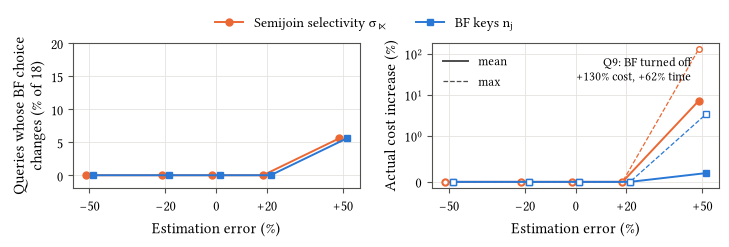

changed  dC_mean  dC_max  dT_mean  dT_max
plan  param level                                          
knee  n     -0.5       0%      0.0     0.0      0.0     0.0
            -0.2       0%      0.0     0.0      0.0     0.0
             0.0       0%      0.0     0.0      0.0     0.0
             0.2       0%      0.0     0.0      0.0     0.0
             0.5       6%      0.2     3.5     -0.1     0.0
      sigma -0.5       0%      0.0     0.0      0.0     0.0
            -0.2       0%      0.0     0.0      0.0     0.0
             0.0       0%      0.0     0.0      0.0     0.0
             0.2       0%      0.0     0.0      0.0     0.0
             0.5       6%      7.2   129.7      3.4    61.6
min_C n     -0.5       6%      0.0     0.0      0.0     0.2
            -0.2       6%      0.0     0.0      0.0     0.2
             0.0      11%      0.0     0.1      0.1     1.3
             0.2       6%      0.0     0.0      0.0     0.2
             0.5       6%      0.0     0.0      0.0     0.2
      sigma -0.5      17%      0.0     0.1      0.1     1.3
            -0.2      17%      0.0     0.1      0.1     1.3
             0.0      11%      0.0     0.1      0.1     1.3
             0.2      17%      0.0     0.1      0.1     1.3
             0.5      22%      7.2   129.7      3.5    61.6
min_T n     -0.5      11%      0.5    13.2      0.4     5.2
            -0.2      11%      0.5    13.2      0.4     5.2
             0.0      11%      0.5    13.2      0.4     5.2
             0.2      17%      0.3    23.0      0.3     2.1
             0.5       6%      1.3    23.0      0.1     2.1
      sigma -0.5      17%     -0.2    13.2      0.5     5.2
            -0.2      17%     -0.2    13.2      0.5     5.2
             0.0      11%      0.5    13.2      0.4     5.2
             0.2      17%      7.8   129.7      3.8    61.6
             0.5      11%      7.9   129.7      3.7    61.6

In [9]:
SENS = pd.read_csv(f"{DATA}/bf-sensitivity.csv")
SENS["dC"] = (SENS.C_true_usd / SENS.C_oracle_usd - 1) * 100
SENS["dT"] = (SENS.T_true_s / SENS.T_oracle_s - 1) * 100

SENS_PLAN = "knee"
SENS_MODE = "systematic"
FIGSIZE_SENS = (7.2, 2.4)
SENS_TEXT = dict(label=FONT_SIZE - 2, tick=FONT_SIZE - 3, legend=FONT_SIZE - 3, note=FONT_SIZE - 4)
SENS_LEGEND = dict(x=0.5, y=1.0, loc="upper center", ncol=2)
SENS_LEGEND_TOP = 0.12
SENS_PAD = dict(pad=0.3, w_pad=1.2)
SENS_PARAM = {"sigma": (r"Semijoin selectivity $\sigma_{\ltimes}$", "#eb6834", "o"), "n": (r"BF keys $n_j$", "#2a78d6", "s")}
SENS_DX = {"sigma": -1.5, "n": 1.5}

d = SENS[(SENS["plan"] == SENS_PLAN) & (SENS["mode"] == SENS_MODE)]
nq = d["query"].nunique()
st = SENS_TEXT
fig, (a1, a2) = plt.subplots(1, 2, figsize=FIGSIZE_SENS)
for prm, (lab, col, mk) in SENS_PARAM.items():
    g = d[d.param == prm].groupby("level")
    x = g.size().index * 100 + SENS_DX[prm]
    flip = (1 - g.same_bfs.mean()) * 100
    a1.plot(x, flip, color=col, marker=mk, ms=5, lw=1.4, label=lab)
    a2.plot(x, g.dC.mean(), color=col, marker=mk, ms=5, lw=1.4)
    a2.plot(x, g.dC.max(), color=col, marker=mk, ms=4, lw=0.9, ls="--", mfc="white")
a1.set_ylabel(f"Queries whose BF choice\nchanges (% of {nq})", fontsize=st["label"])
a2.set_ylabel("Actual cost increase (%)", fontsize=st["label"])
a2.set_yscale("symlog", linthresh=1)
a2.plot([], [], color="0.3", lw=1.4, label="mean"); a2.plot([], [], color="0.3", lw=0.9, ls="--", label="max")
a2.legend(fontsize=st["note"], loc="upper left", frameon=False)
big = d[d.dC == d.dC.max()].iloc[0]
if big.dC > 10:
    a2.annotate(f"{big['query'].upper()}: BF turned off\n+{big.dC:.0f}% cost, +{big.dT:.0f}% time",
                (big.level * 100, big.dC), xytext=(-8, -4), textcoords="offset points", ha="right", va="top",
                fontsize=st["note"])
for a in (a1, a2):
    a.set_xticks([-50, -20, 0, 20, 50], ["−50", "−20", "0", "+20", "+50"])
    a.set_xlabel("Estimation error (%)", fontsize=st["label"])
    a.tick_params(labelsize=st["tick"])
    a.grid(True, color=style.GRID, lw=0.6); a.set_axisbelow(True)
a1.set_ylim(-2, max(20, a1.get_ylim()[1]))
lg = dict(SENS_LEGEND)
fig.legend(*a1.get_legend_handles_labels(), loc=lg.pop("loc"), bbox_to_anchor=(lg.pop("x"), lg.pop("y")),
           fontsize=st["legend"], frameon=False, **lg)
fig.tight_layout(**SENS_PAD, rect=(0, 0, 1, 1 - SENS_LEGEND_TOP))
style.save(fig, FIG, "bf-sensitivity")
plt.show()
SENS[SENS["mode"] == SENS_MODE].groupby(["plan", "param", "level"]).agg(
    changed=("same_bfs", lambda s: f"{1 - s.mean():.0%}"), dC_mean=("dC", "mean"), dC_max=("dC", "max"),
    dT_mean=("dT", "mean"), dT_max=("dT", "max")).round(1)